# Lab1: Iris Classification & Polynomial Regression
Author: YAN XINYU
Date: 2026-04-10

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [29]:
# Part 1: Iris Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
column_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
data = pd.read_csv(url, names=column_names)
data['species'] = data['species'].apply(lambda x: 1 if x == 'Iris-setosa' else 0)
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


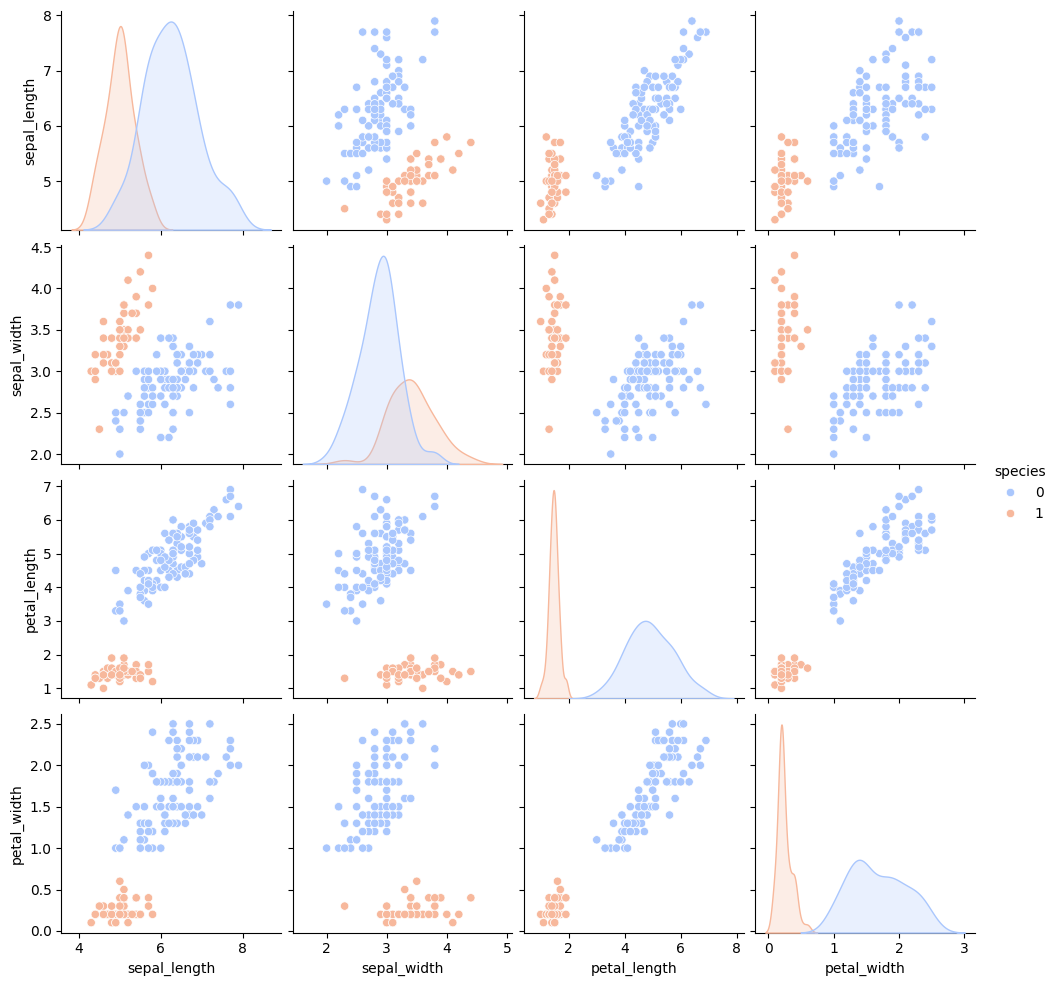

In [30]:
sns.pairplot(data, hue="species", diag_kind="kde", palette="coolwarm")
plt.show()

In [31]:
X = data.drop("species", axis=1)
y = data["species"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
log_reg = LogisticRegression(solver='liblinear', penalty='l2', C=0.5)
log_reg.fit(X_train, y_train)

LogisticRegression(C=0.5, solver='liblinear')

In [35]:
y_pred = log_reg.predict(X_test)

In [36]:
print("Classification report:")
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        19

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [37]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(conf_matrix)

Confusion matrix:
[[26  0]
 [ 0 19]]


In [38]:
cv_score = cross_val_score(log_reg, X, y, cv=5)
print(f"cross_val_score: {cv_score.mean()}")

cross_val_score: 1.0


In [39]:
train_accuracy = log_reg.score(X_train, y_train)
test_accuracy = log_reg.score(X_test, y_test)
print(f"train_accuracy: {train_accuracy}")
print(f"test_accuracy: {test_accuracy}")

train_accuracy: 1.0
test_accuracy: 1.0


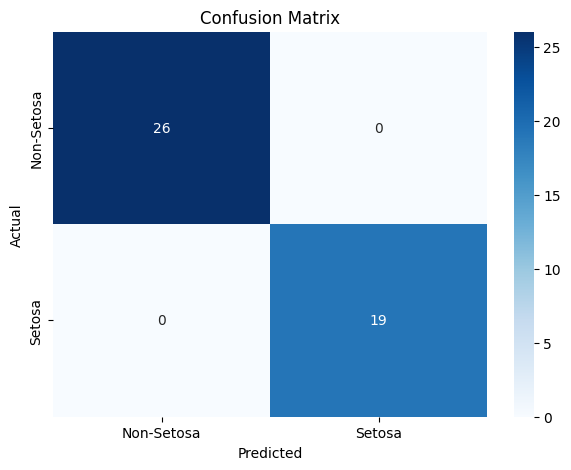

In [40]:
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Setosa', 'Setosa'], yticklabels=['Non-Setosa', 'Setosa'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
# Part 2: Polynomial Regression - Original Example
np.random.seed(0)
X_poly = np.sort(np.random.rand(120, 1) * 10, axis=0)
y_poly = (0.5 * X_poly**2 - 3 * X_poly + 10) + np.random.randn(120, 1) * 5

In [42]:
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.3, random_state=42)

In [43]:
def fit_poly_and_eval(degree):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_train_d = poly.fit_transform(X_train_poly)
    X_test_d = poly.transform(X_test_poly)
    model = LinearRegression()
    model.fit(X_train_d, y_train_poly)
    y_train_pred = model.predict(X_train_d)
    y_test_pred = model.predict(X_test_d)
    train_mse = mean_squared_error(y_train_poly, y_train_pred)
    test_mse = mean_squared_error(y_test_poly, y_test_pred)
    return poly, model, train_mse, test_mse

In [44]:
configs_poly = [1, 3, 15]
results_poly = {d: fit_poly_and_eval(d) for d in configs_poly}

In [45]:
x_grid = np.linspace(X_poly.min(), X_poly.max(), 400).reshape(-1, 1)
plt.figure(figsize=(16, 4))

<Figure size 1600x400 with 0 Axes>

<Figure size 1600x400 with 0 Axes>

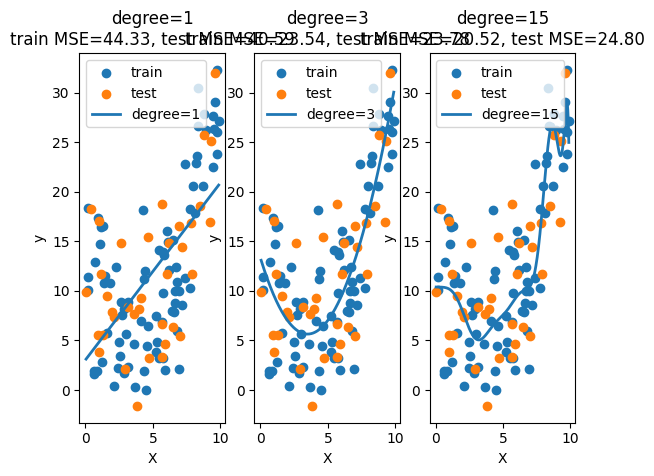

In [46]:
for i, d in enumerate(configs_poly, start=1):
    poly, model, train_mse, test_mse = results_poly[d]
    y_grid = model.predict(poly.transform(x_grid))
    plt.subplot(1, 3, i)
    plt.scatter(X_train_poly, y_train_poly, label="train")
    plt.scatter(X_test_poly, y_test_poly, label="test")
    plt.plot(x_grid, y_grid, linewidth=2, label=f"degree={d}")
    plt.title(f"degree={d}\ntrain MSE={train_mse:.2f}, test MSE={test_mse:.2f}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()

In [47]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [48]:
for d in configs_poly:
    _, _, train_mse, test_mse = results_poly[d]
    print(f"Degree={d}: train MSE={train_mse:.4f}, test MSE={test_mse:.4f}")

Degree=1: train MSE=44.3337, test MSE=40.5857
Degree=3: train MSE=23.5376, test MSE=23.7773
Degree=15: train MSE=20.5165, test MSE=24.8028


In [49]:
# Part 3: Polynomial Regression - Your Provided Example
np.random.seed(0)
X = np.sort(np.random.rand(120, 1) * 10, axis=0)
y = (0.5 * X**2 - 3 * X + 10) + np.random.randn(120, 1) * 5

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [51]:
def fit_poly_and_eval_user(degree: int):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    return poly, model, train_mse, test_mse  # ✅ 正确缩进



In [52]:
configs_user = [1, 3, 15]
results_user = {}
for d in configs_user:
    results_user[d] = fit_poly_and_eval_user(d)

In [53]:
x_grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)

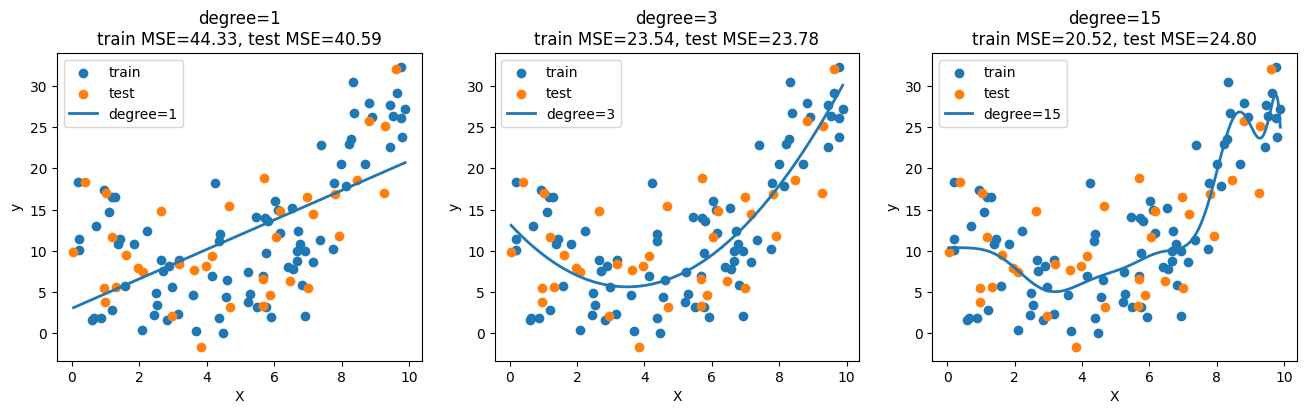

In [54]:
plt.figure(figsize=(16, 4))
for i, d in enumerate(configs_user, start=1):
    poly, model, train_mse, test_mse = results_user[d]
    y_grid = model.predict(poly.transform(x_grid))
    plt.subplot(1, 3, i)
    plt.scatter(X_train, y_train, label="train")
    plt.scatter(X_test, y_test, label="test")
    plt.plot(x_grid, y_grid, linewidth=2, label=f"degree={d}")
    plt.title(f"degree={d}\ntrain MSE={train_mse:.2f}, test MSE={test_mse:.2f}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()

In [55]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [56]:
for d in configs_user:
    _, _, train_mse, test_mse = results_user[d]
    print(f"Degree={d}: train MSE={train_mse:.4f}, test MSE={test_mse:.4f}")

Degree=1: train MSE=44.3337, test MSE=40.5857
Degree=3: train MSE=23.5376, test MSE=23.7773
Degree=15: train MSE=20.5165, test MSE=24.8028
